##End to End analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler, Normalizer

In [ ]:

df = pd.read_csv('/content/drive/MyDrive/Datasets_lecture/bangalore.csv')
df.head()

,Hotel Name,Rating,Rating Description,Reviews,Star Rating,Location,Nearest Landmark,Distance to Landmark,Price,Tax
0,The Park Bangalore,3.9,Very Good,4187.0,5.0,Ulsoor,NaN,NaN,"7,567","2,254"
1,"Keys Select by Lemon Tree Hotels, Whitefield, ...",4.0,Very Good,2201.0,4.0,Brookefield,NaN,NaN,"1,509",531
2,ITC Windsor - A Luxury Collection Hotel,4.4,Excellent,1315.0,5.0,Vasanth Nagar,Bangalore Palace,2.4 km,"9,900",NaN
3,Lemon Tree Premier Ulsoor Lake Bangalore,4.0,Very Good,5089.0,5.0,Sivanchetti Gardens,Ulsoor Lake,770 m,"2,347",918
4,"Keys Select by Lemon Tree Hotels, Hosur Road, ...",4.0,Very Good,3290.0,4.0,Hosur road,NaN,NaN,"2,522","1,014"


In [ ]:
df

,Hotel Name,Rating,Rating Description,Reviews,Star Rating,Location,Nearest Landmark,Distance to Landmark,Price,Tax
0,The Park Bangalore,3.9,Very Good,4187.0,5.0,Ulsoor,NaN,NaN,"7,567","2,254"
1,"Keys Select by Lemon Tree Hotels, Whitefield, ...",4.0,Very Good,2201.0,4.0,Brookefield,NaN,NaN,"1,509",531
2,ITC Windsor - A Luxury Collection Hotel,4.4,Excellent,1315.0,5.0,Vasanth Nagar,Bangalore Palace,2.4 km,"9,900",NaN
3,Lemon Tree Premier Ulsoor Lake Bangalore,4.0,Very Good,5089.0,5.0,Sivanchetti Gardens,Ulsoor Lake,770 m,"2,347",918
4,"Keys Select by Lemon Tree Hotels, Hosur Road, ...",4.0,Very Good,3290.0,4.0,Hosur road,NaN,NaN,"2,522","1,014"
...,...,...,...,...,...,...,...,...,...,...
96,Shravanthi Sarovar Portico JP Nagar,3.6,Very Good,139.0,4.0,Outer Ring Road,NaN,NaN,"3,977",804
97,"Vivanta Bengaluru, Whitefield",4.3,Excellent,959.0,5.0,Whitefield,NaN,NaN,"7,500",NaN
98,Melange Astris\nLike a 3,4.1,Very Good,1006.0,NaN,Richmond road,Cubbon Park,2.5 km,"4,300",969
99,Octave Church Inn,3.5,Very Good,712.0,3.0,Church Street,MG Road,94 m,"1,669",337


In [ ]:
df.shape

(101, 10)

#Identifying Null Values

In [ ]:
df.isnull()

,Hotel Name,Rating,Rating Description,Reviews,Star Rating,Location,Nearest Landmark,Distance to Landmark,Price,Tax
0,False,False,False,False,False,False,True,True,False,False
1,False,False,False,False,False,False,True,True,False,False
2,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...
96,False,False,False,False,False,False,True,True,False,False
97,False,False,False,False,False,False,True,True,False,True
98,False,False,False,False,True,False,False,False,False,False
99,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Hotel Name,0
Rating,1
Rating Description,1
Reviews,1
Star Rating,15
Location,0
Nearest Landmark,67
Distance to Landmark,67
Price,0
Tax,37


In [ ]:
len(df)

101

In [ ]:
df.isnull().sum()/len(df)

,0
Hotel Name,0.000000
Rating,0.009901
Rating Description,0.009901
Reviews,0.009901
Star Rating,0.148515
Location,0.000000
Nearest Landmark,0.663366
Distance to Landmark,0.663366
Price,0.000000
Tax,0.366337


In [ ]:
df.isnull().sum()/len(df) *100

,0
Hotel Name,0.000000
Rating,0.990099
Rating Description,0.990099
Reviews,0.990099
Star Rating,14.851485
Location,0.000000
Nearest Landmark,66.336634
Distance to Landmark,66.336634
Price,0.000000
Tax,36.633663


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Hotel Name            101 non-null    object 
 1   Rating                100 non-null    float64
 2   Rating Description    100 non-null    object 
 3   Reviews               100 non-null    float64
 4   Star Rating           86 non-null     float64
 5   Location              101 non-null    object 
 6   Nearest Landmark      34 non-null     object 
 7   Distance to Landmark  34 non-null     object 
 8   Price                 101 non-null    object 
 9   Tax                   64 non-null     object 
dtypes: float64(3), object(7)
memory usage: 8.0+ KB


##Handling Null Values

In [ ]:
df["Distance to Landmark"]

,Distance to Landmark
0,NaN
1,NaN
2,2.4 km
3,770 m
4,NaN
...,...
96,NaN
97,NaN
98,2.5 km
99,94 m


In [ ]:
df['Nearest Landmark']

,Nearest Landmark
0,NaN
1,NaN
2,Bangalore Palace
3,Ulsoor Lake
4,NaN
...,...
96,NaN
97,NaN
98,Cubbon Park
99,MG Road


In [ ]:
df = df.drop(['Nearest Landmark'], axis=1)

In [ ]:
df

,Hotel Name,Rating,Rating Description,Reviews,Star Rating,Location,Distance to Landmark,Price,Tax
0,The Park Bangalore,3.9,Very Good,4187.0,5.0,Ulsoor,NaN,"7,567","2,254"
1,"Keys Select by Lemon Tree Hotels, Whitefield, ...",4.0,Very Good,2201.0,4.0,Brookefield,NaN,"1,509",531
2,ITC Windsor - A Luxury Collection Hotel,4.4,Excellent,1315.0,5.0,Vasanth Nagar,2.4 km,"9,900",NaN
3,Lemon Tree Premier Ulsoor Lake Bangalore,4.0,Very Good,5089.0,5.0,Sivanchetti Gardens,770 m,"2,347",918
4,"Keys Select by Lemon Tree Hotels, Hosur Road, ...",4.0,Very Good,3290.0,4.0,Hosur road,NaN,"2,522","1,014"
...,...,...,...,...,...,...,...,...,...
96,Shravanthi Sarovar Portico JP Nagar,3.6,Very Good,139.0,4.0,Outer Ring Road,NaN,"3,977",804
97,"Vivanta Bengaluru, Whitefield",4.3,Excellent,959.0,5.0,Whitefield,NaN,"7,500",NaN
98,Melange Astris\nLike a 3,4.1,Very Good,1006.0,NaN,Richmond road,2.5 km,"4,300",969
99,Octave Church Inn,3.5,Very Good,712.0,3.0,Church Street,94 m,"1,669",337


In [ ]:
# df.drop(['Nearest Landmark','Distance to Landmark'], axis = 1, inplace = True) # Dropping multiple columns with null values

In [ ]:
df.drop(['Distance to Landmark'], axis = 1, inplace = True)

In [ ]:
df

,Hotel Name,Rating,Rating Description,Reviews,Star Rating,Location,Price,Tax
0,The Park Bangalore,3.9,Very Good,4187.0,5.0,Ulsoor,"7,567","2,254"
1,"Keys Select by Lemon Tree Hotels, Whitefield, ...",4.0,Very Good,2201.0,4.0,Brookefield,"1,509",531
2,ITC Windsor - A Luxury Collection Hotel,4.4,Excellent,1315.0,5.0,Vasanth Nagar,"9,900",NaN
3,Lemon Tree Premier Ulsoor Lake Bangalore,4.0,Very Good,5089.0,5.0,Sivanchetti Gardens,"2,347",918
4,"Keys Select by Lemon Tree Hotels, Hosur Road, ...",4.0,Very Good,3290.0,4.0,Hosur road,"2,522","1,014"
...,...,...,...,...,...,...,...,...
96,Shravanthi Sarovar Portico JP Nagar,3.6,Very Good,139.0,4.0,Outer Ring Road,"3,977",804
97,"Vivanta Bengaluru, Whitefield",4.3,Excellent,959.0,5.0,Whitefield,"7,500",NaN
98,Melange Astris\nLike a 3,4.1,Very Good,1006.0,NaN,Richmond road,"4,300",969
99,Octave Church Inn,3.5,Very Good,712.0,3.0,Church Street,"1,669",337


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Hotel Name          101 non-null    object 
 1   Rating              100 non-null    float64
 2   Rating Description  100 non-null    object 
 3   Reviews             100 non-null    float64
 4   Star Rating         86 non-null     float64
 5   Location            101 non-null    object 
 6   Price               101 non-null    object 
 7   Tax                 64 non-null     object 
dtypes: float64(3), object(5)
memory usage: 6.4+ KB


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
Hotel Name,0.000000
Rating,0.990099
Rating Description,0.990099
Reviews,0.990099
Star Rating,14.851485
Location,0.000000
Price,0.000000
Tax,36.633663


In [ ]:
df.mean(numeric_only=True)

,0
Rating,4.038000
Reviews,1228.830000
Star Rating,4.081395


In [ ]:
df.median(numeric_only=True)

,0
Rating,4.05
Reviews,984.50
Star Rating,4.00


In [ ]:
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

In [ ]:
df

,Hotel Name,Rating,Rating Description,Reviews,Star Rating,Location,Price,Tax
0,The Park Bangalore,3.9,Very Good,4187.0,5.0,Ulsoor,"7,567","2,254"
1,"Keys Select by Lemon Tree Hotels, Whitefield, ...",4.0,Very Good,2201.0,4.0,Brookefield,"1,509",531
2,ITC Windsor - A Luxury Collection Hotel,4.4,Excellent,1315.0,5.0,Vasanth Nagar,"9,900",NaN
3,Lemon Tree Premier Ulsoor Lake Bangalore,4.0,Very Good,5089.0,5.0,Sivanchetti Gardens,"2,347",918
4,"Keys Select by Lemon Tree Hotels, Hosur Road, ...",4.0,Very Good,3290.0,4.0,Hosur road,"2,522","1,014"
...,...,...,...,...,...,...,...,...
96,Shravanthi Sarovar Portico JP Nagar,3.6,Very Good,139.0,4.0,Outer Ring Road,"3,977",804
97,"Vivanta Bengaluru, Whitefield",4.3,Excellent,959.0,5.0,Whitefield,"7,500",NaN
98,Melange Astris\nLike a 3,4.1,Very Good,1006.0,NaN,Richmond road,"4,300",969
99,Octave Church Inn,3.5,Very Good,712.0,3.0,Church Street,"1,669",337


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
Hotel Name,0.000000
Rating,0.000000
Rating Description,0.990099
Reviews,0.990099
Star Rating,14.851485
Location,0.000000
Price,0.000000
Tax,36.633663


#Fill all the null Values either with Mean / Median /Mode


In [ ]:
df['Rating Description'] = df['Rating Description'].fillna(df['Rating Description'].mode()[0])
df['Reviews'] = df['Reviews'].fillna(df['Reviews'].median())
df['Star Rating'] = df['Star Rating'].fillna(df['Star Rating'].median())
df['Tax'] = df['Tax'].fillna(df['Tax'].mode()[0])

In [ ]:
df

,Hotel Name,Rating,Rating Description,Reviews,Star Rating,Location,Price,Tax
0,The Park Bangalore,3.9,Very Good,4187.0,5.0,Ulsoor,"7,567","2,254"
1,"Keys Select by Lemon Tree Hotels, Whitefield, ...",4.0,Very Good,2201.0,4.0,Brookefield,"1,509",531
2,ITC Windsor - A Luxury Collection Hotel,4.4,Excellent,1315.0,5.0,Vasanth Nagar,"9,900",564
3,Lemon Tree Premier Ulsoor Lake Bangalore,4.0,Very Good,5089.0,5.0,Sivanchetti Gardens,"2,347",918
4,"Keys Select by Lemon Tree Hotels, Hosur Road, ...",4.0,Very Good,3290.0,4.0,Hosur road,"2,522","1,014"
...,...,...,...,...,...,...,...,...
96,Shravanthi Sarovar Portico JP Nagar,3.6,Very Good,139.0,4.0,Outer Ring Road,"3,977",804
97,"Vivanta Bengaluru, Whitefield",4.3,Excellent,959.0,5.0,Whitefield,"7,500",564
98,Melange Astris\nLike a 3,4.1,Very Good,1006.0,4.0,Richmond road,"4,300",969
99,Octave Church Inn,3.5,Very Good,712.0,3.0,Church Street,"1,669",337


# All the data Has to Fill and It should show Zero like below before doing further analysis.

In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
Hotel Name,0.0
Rating,0.0
Rating Description,0.0
Reviews,0.0
Star Rating,0.0
Location,0.0
Price,0.0
Tax,0.0


In [ ]:
df.describe()

,Rating,Reviews,Star Rating
count,100.000000,100.000000,86.000000
mean,4.038000,1228.830000,4.081395
std,0.351269,1051.214901,0.814791
min,3.000000,13.000000,3.000000
25%,3.800000,492.000000,3.000000
50%,4.050000,984.500000,4.000000
75%,4.300000,1723.750000,5.000000
max,4.800000,5089.000000,5.000000


##Finding Duplicates

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
96,False
97,False
98,False
99,False


In [ ]:
# Checking for duplicates

df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(101, 8)

In [ ]:
df = df.drop_duplicates() # code to drop the duplicates if we have any

## Before Scaling Data Visualization

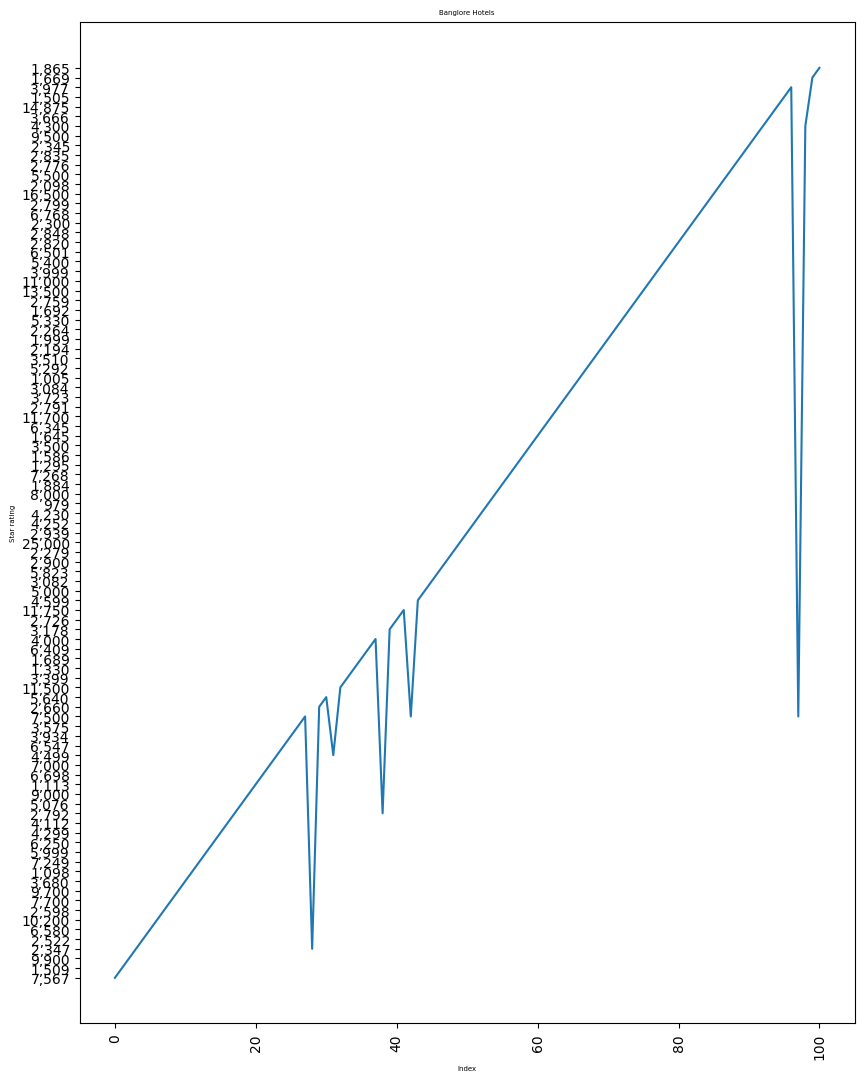

In [ ]:
#line plot
plt.figure(figsize = (10,13))
plt.plot(df["Price"])
plt.title("Banglore Hotels",fontsize = 5)
plt.ylabel("Star rating",fontsize = 5)
plt.xlabel("Index", fontsize = 5)
plt.xticks(rotation = 90)
plt.show()

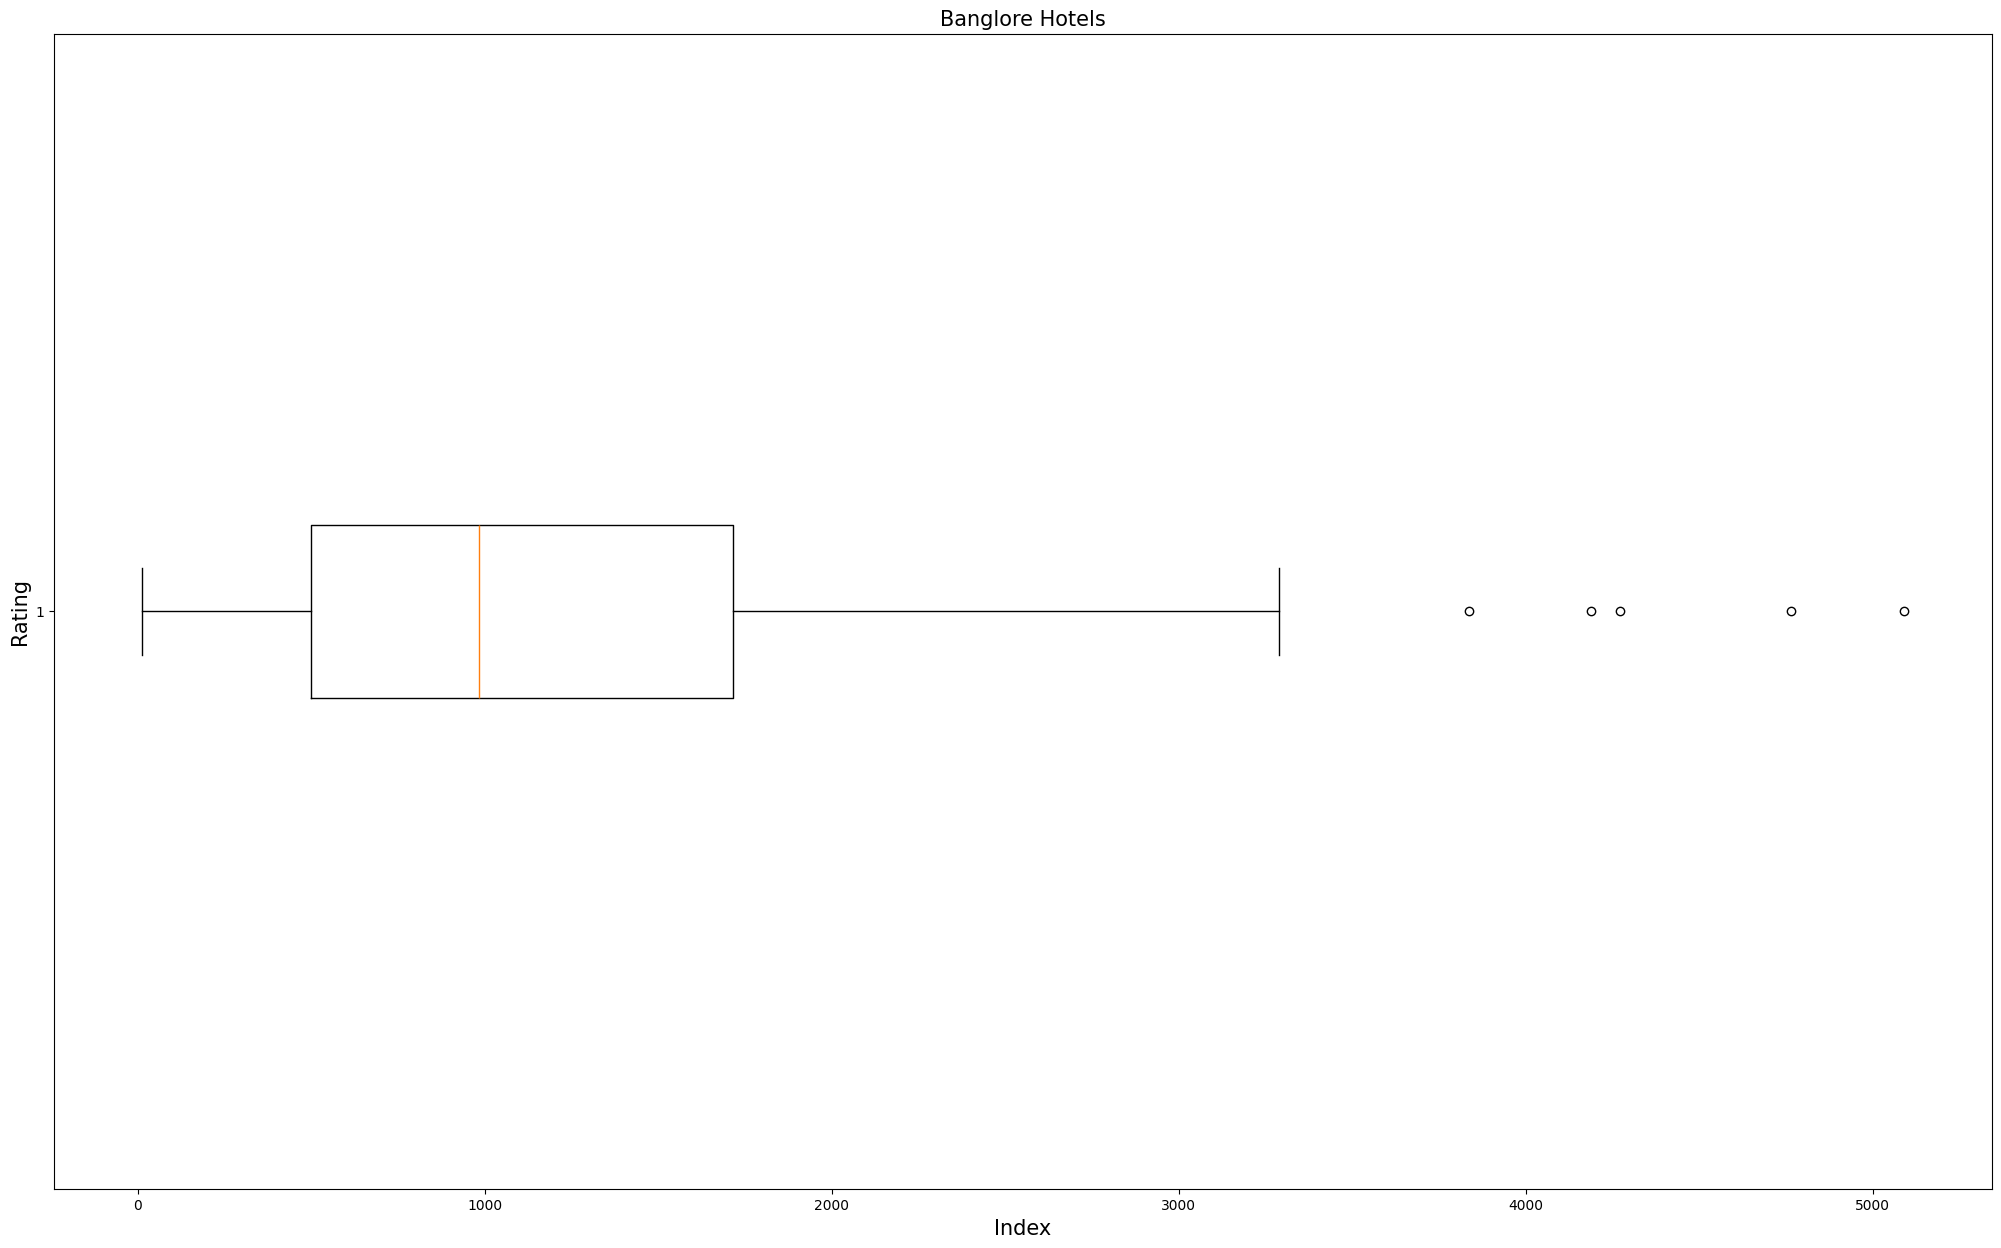

In [ ]:
#Box plot
plt.figure(figsize = (25,15))
plt.boxplot(df["Reviews"], vert = False)
plt.title("Banglore Hotels",fontsize = 15)
plt.ylabel("Rating",fontsize = 15)
plt.xlabel("Index", fontsize = 15)

plt.show()

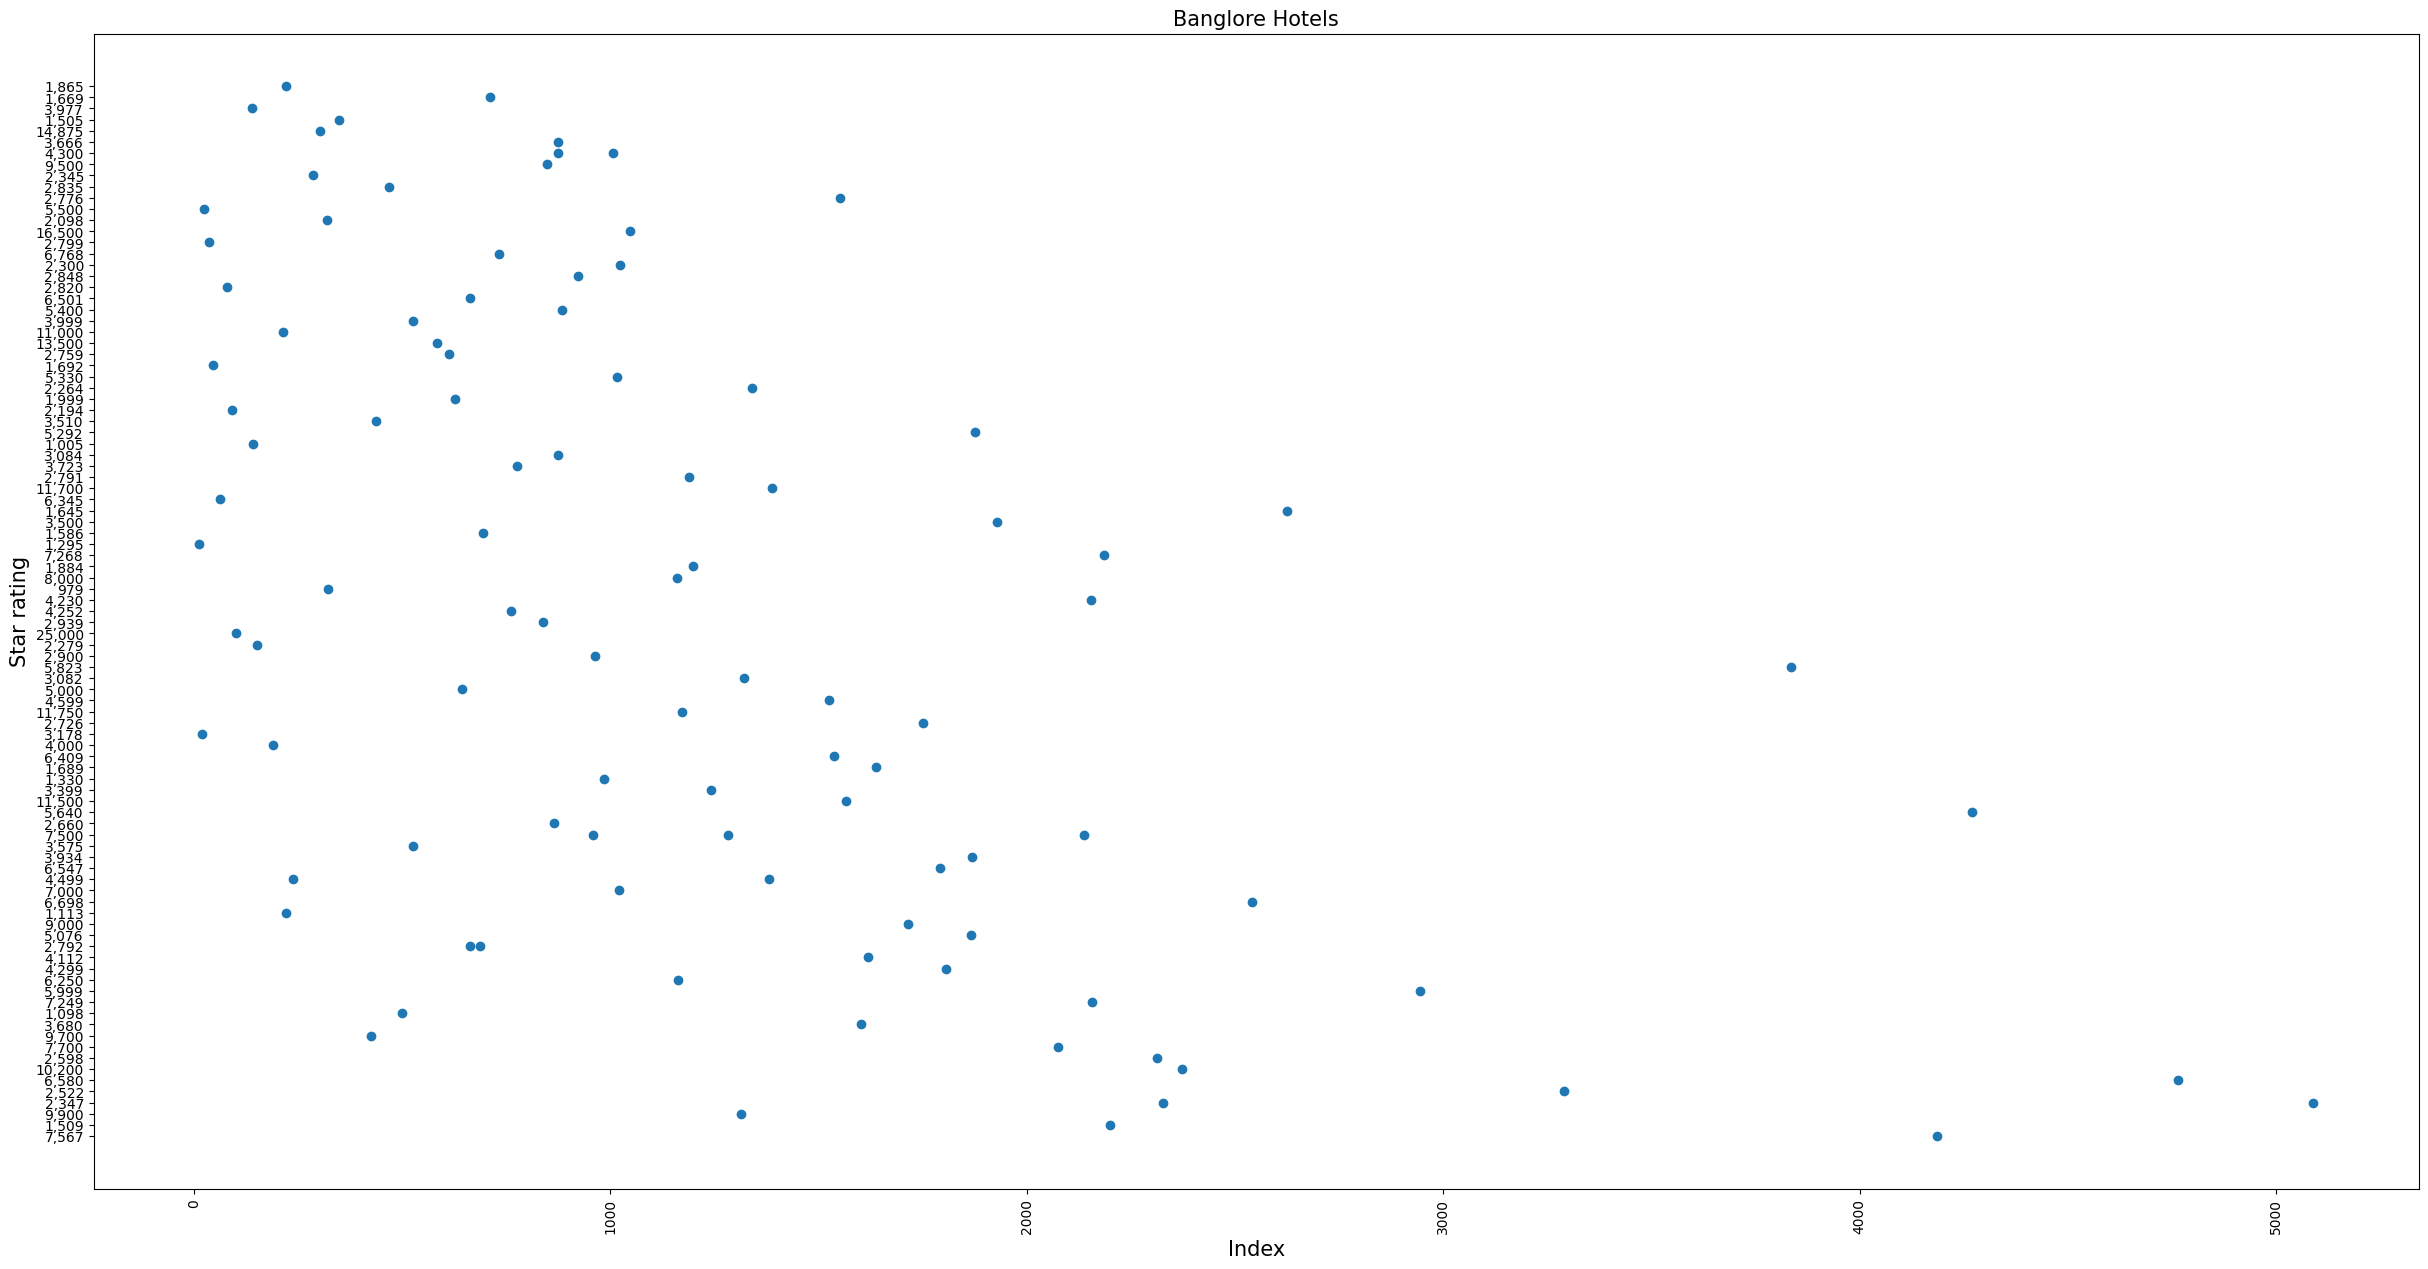

In [ ]:
#Scatter plot
plt.figure(figsize = (30,15))
plt.scatter(df['Reviews'], df['Price'])
plt.title("Banglore Hotels",fontsize = 15)
plt.ylabel("Star rating",fontsize = 15)
plt.xlabel("Index", fontsize = 15)
plt.xticks(rotation = 90)
plt.show()

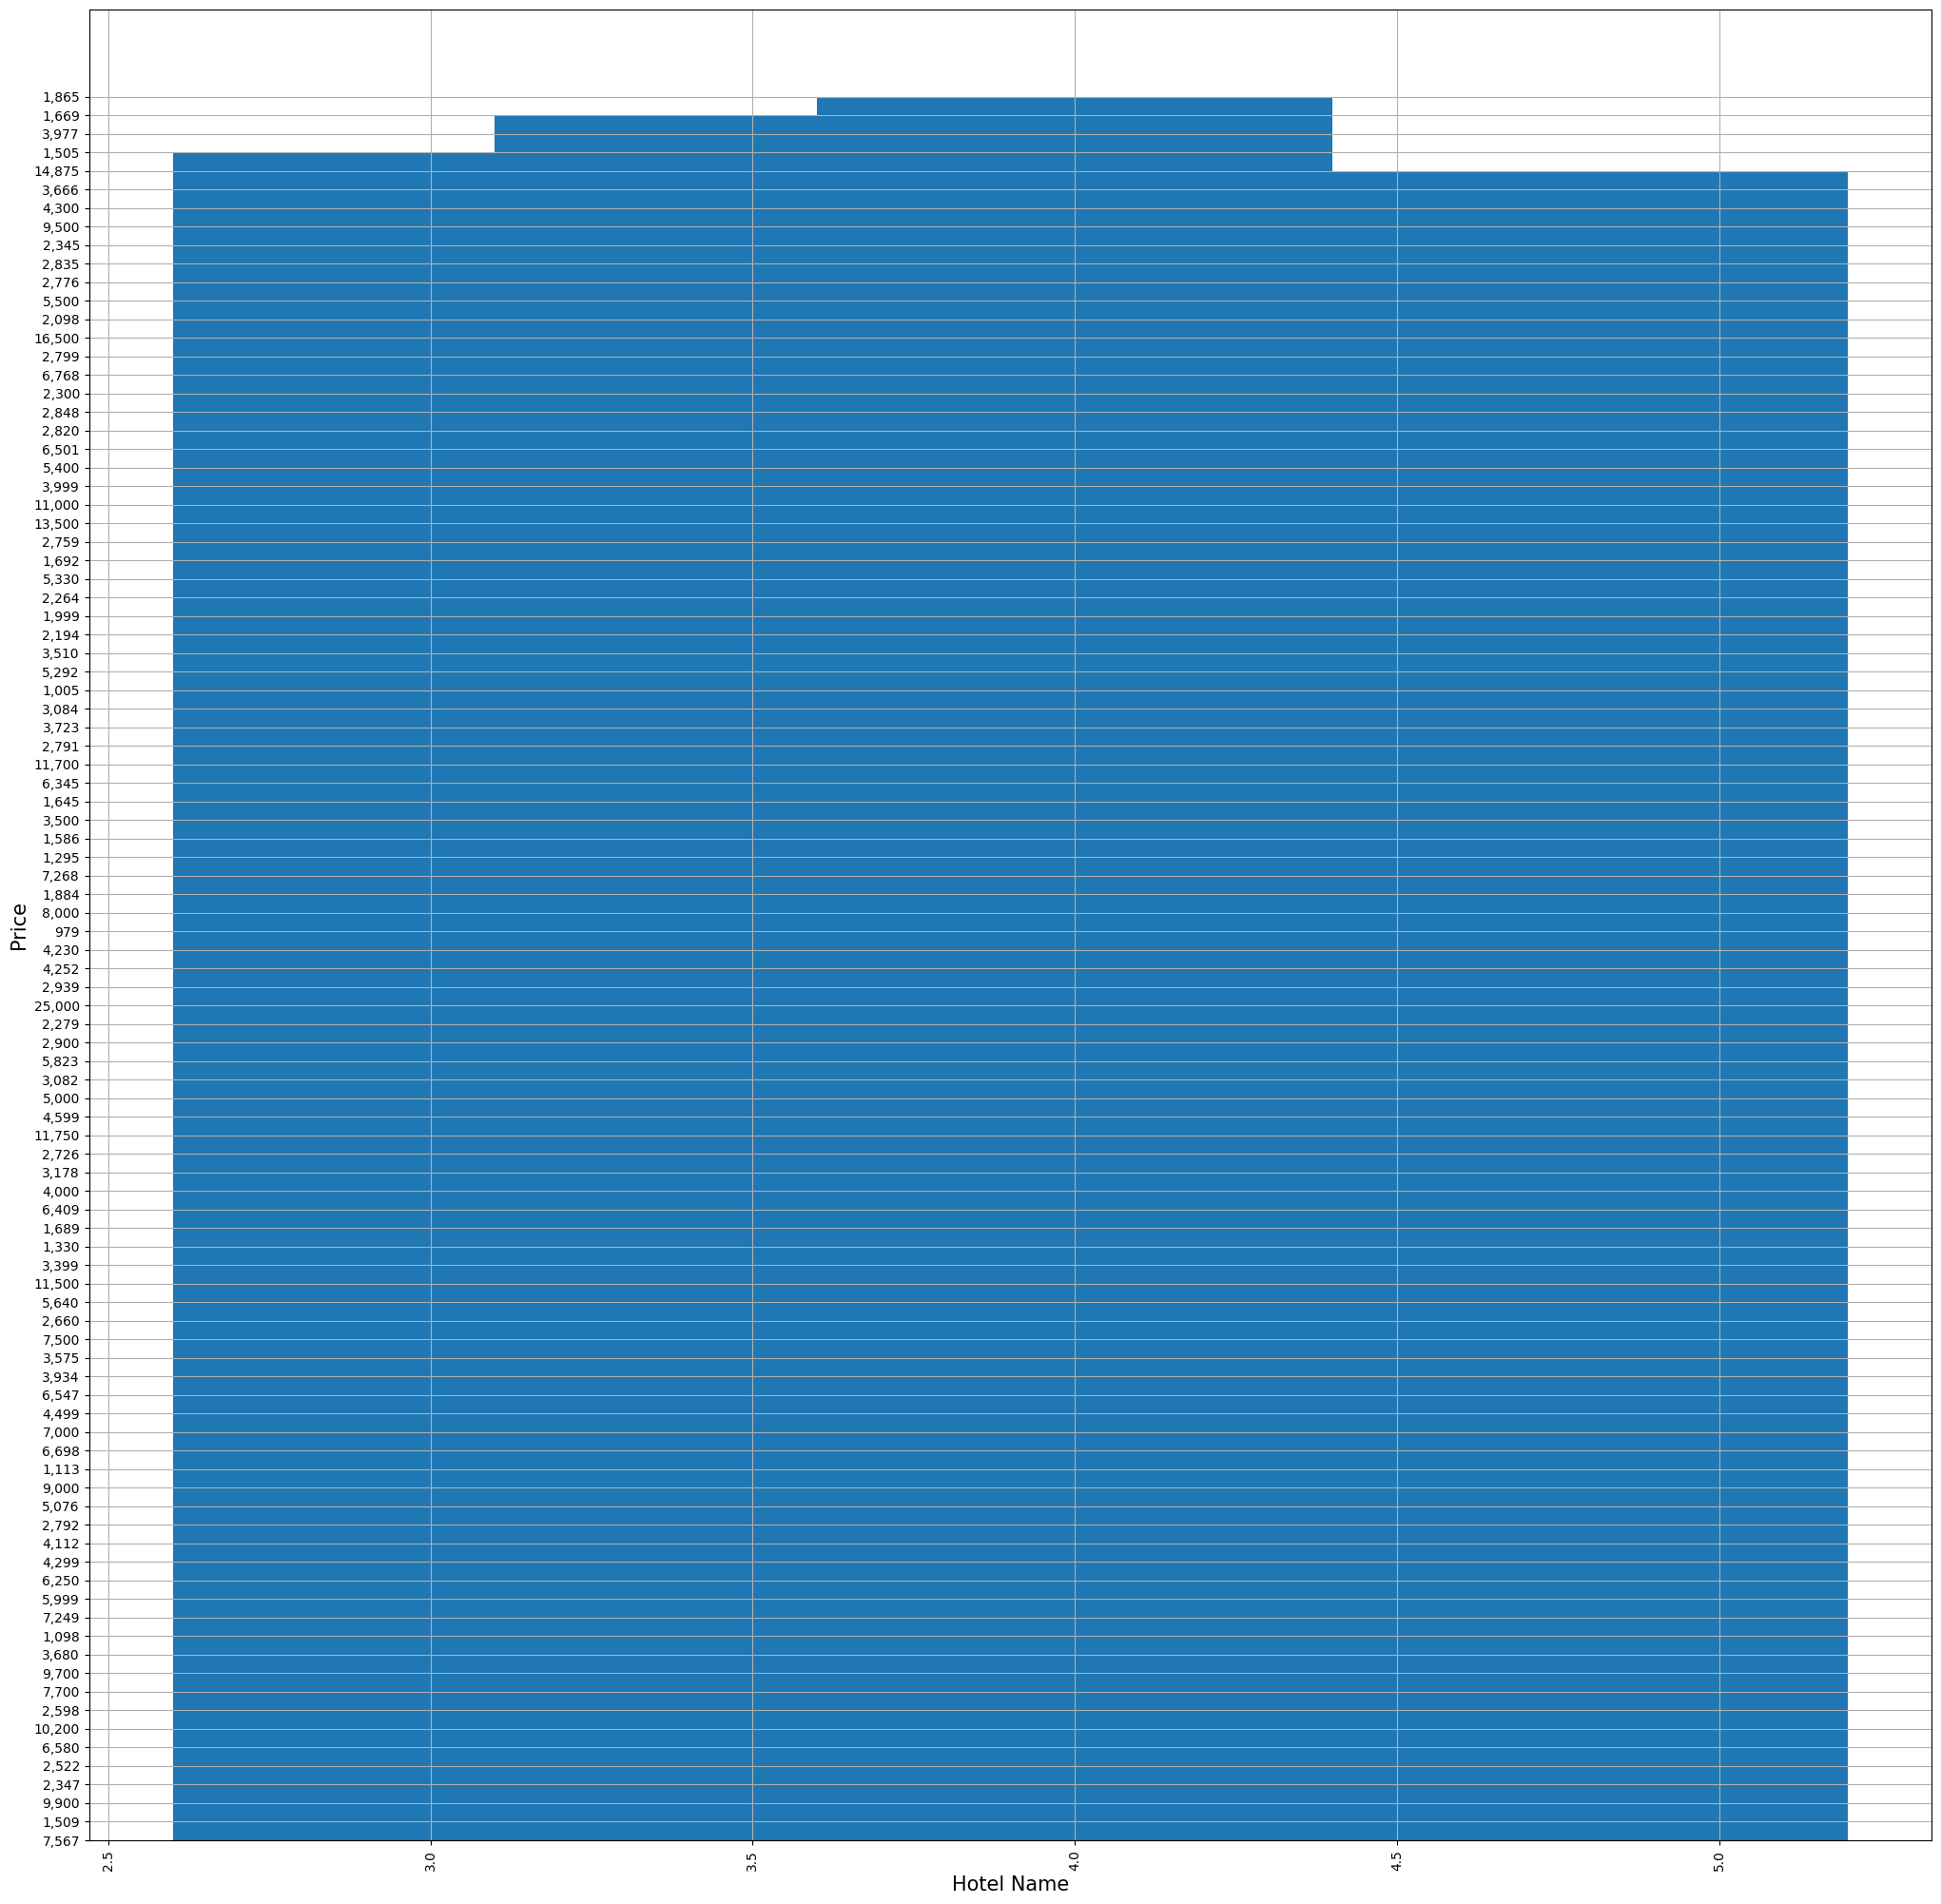

In [ ]:
#Bar plot
plt.figure(figsize = (25,25))
plt.bar(df['Rating'], df['Price'])
plt.ylabel("Price",fontsize = 15)
plt.xlabel("Hotel Name", fontsize = 15)
plt.xticks(rotation = 90)
plt.grid()

plt.savefig("Bar_banglore")
plt.show()

##Seaborn before scaling

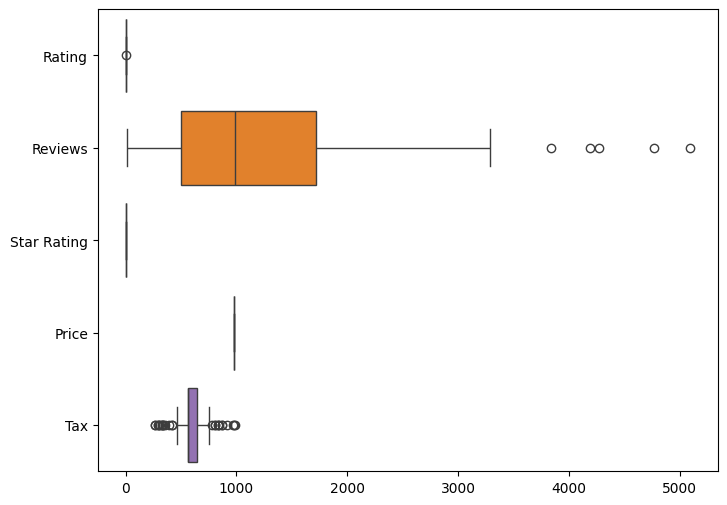

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, orient='h')
plt.show()

##String to numerical conversion - Numeric should be 1234 , should not be like 1,234

In [ ]:
df['Price'] = pd.to_numeric(df['Price'].str.replace(',', ''), errors='coerce')
df['Tax'] = pd.to_numeric(df['Tax'].str.replace(',', ''), errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Hotel Name          101 non-null    object 
 1   Rating              101 non-null    float64
 2   Rating Description  101 non-null    object 
 3   Reviews             101 non-null    float64
 4   Star Rating         101 non-null    float64
 5   Location            101 non-null    object 
 6   Price               101 non-null    int64  
 7   Tax                 101 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 6.4+ KB


#IQR (Interquartile Range) - Provides you How many outliers are there,If any one column in a row has an outlier, The entire row gets removed, So only if necessary remove outliers other wise don't do it. Since in this dataset there are no much outliers we are not deleting.

In [ ]:
Q1 = df[['Rating', 'Reviews', 'Star Rating', 'Price', 'Tax']].quantile(0.25)
Q3 = df[['Rating', 'Reviews', 'Star Rating', 'Price', 'Tax']].quantile(0.75)
IQR = Q3 - Q1

# Define Outlier Range
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detecting Outliers
outliers = (df[['Rating', 'Reviews', 'Star Rating', 'Price', 'Tax']] < lower_bound) | (df[['Rating', 'Reviews', 'Star Rating', 'Price', 'Tax']] > upper_bound)
print("\nOutliers detected:\n", outliers.sum())



Outliers detected:
 Rating         1
Reviews        5
Star Rating    0
Price          4
Tax            9
dtype: int64


#Categorical Encoding - Can be used either Label or One hot encodig use any one. Choose the correct columns to be labelled.

In [ ]:
# Label Encoding
le = LabelEncoder()

df['Rating Description'] = le.fit_transform(df['Rating Description'])
df['Location'] = le.fit_transform(df['Location'])

# One-Hot Encoding
df = pd.get_dummies(df, columns=['Location','Rating Description'])
print(df.head())

                                          Hotel Name  Rating  Reviews  \
0                                 The Park Bangalore     3.9   4187.0   
1  Keys Select by Lemon Tree Hotels, Whitefield, ...     4.0   2201.0   
2            ITC Windsor - A Luxury Collection Hotel     4.4   1315.0   
3           Lemon Tree Premier Ulsoor Lake Bangalore     4.0   5089.0   
4  Keys Select by Lemon Tree Hotels, Hosur Road, ...     4.0   3290.0   

   Star Rating  Price   Tax  Location_0  Location_1  Location_2  Location_3  \
0          5.0   7567  2254       False       False       False       False   
1          4.0   1509   531       False       False       False        True   
2          5.0   9900   564       False       False       False       False   
3          5.0   2347   918       False       False       False       False   
4          4.0   2522  1014       False       False       False       False   

   ...  Location_30  Location_31  Location_32  Location_33  Location_34  \
0  ...     

#Scaling techniques - Use any one Scaling technique

In [ ]:
#'MinMax': MinMaxScaler(), - Converts values between 0 and 1
#'Standard': StandardScaler(), - Converts data to mean = 0 and std = 1
#'Normalize': Normalizer() - Normalizer does NOT give a fixed range like 0–1 for each column

In [ ]:
scaler = StandardScaler()
num_cols = ['Rating', 'Reviews', 'Star Rating', 'Price', 'Tax']
df[num_cols] = scaler.fit_transform(df[num_cols])
print(df.head())

                                          Hotel Name    Rating   Reviews  \
0                                 The Park Bangalore -0.397149  2.843888   
1  Keys Select by Lemon Tree Hotels, Whitefield, ... -0.109607  0.936172   
2            ITC Windsor - A Luxury Collection Hotel  1.040559  0.085097   
3           Lemon Tree Premier Ulsoor Lake Bangalore -0.109607  3.710332   
4  Keys Select by Lemon Tree Hotels, Hosur Road, ... -0.109607  1.982246   

   Star Rating     Price       Tax  Location_0  Location_1  Location_2  \
0     1.244188  0.682383  4.675436       False       False       False   
1    -0.092652 -0.931483 -0.485117       False       False       False   
2     1.244188  1.303900 -0.386279       False       False       False   
3     1.244188 -0.708237  0.673986       False       False       False   
4    -0.092652 -0.661617  0.961515       False       False       False   

   Location_3  ...  Location_30  Location_31  Location_32  Location_33  \
0       False  ...      

#Matplot lib and seaborn Visuals - After scaling

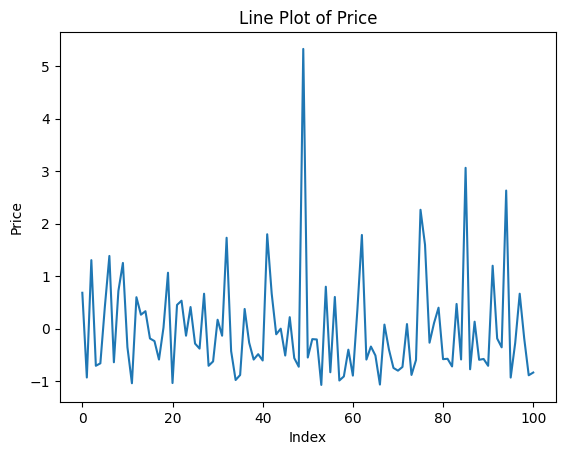

In [ ]:
plt.plot(df['Price'])
plt.title("Line Plot of Price")
plt.xlabel("Index")
plt.ylabel("Price")
plt.show()

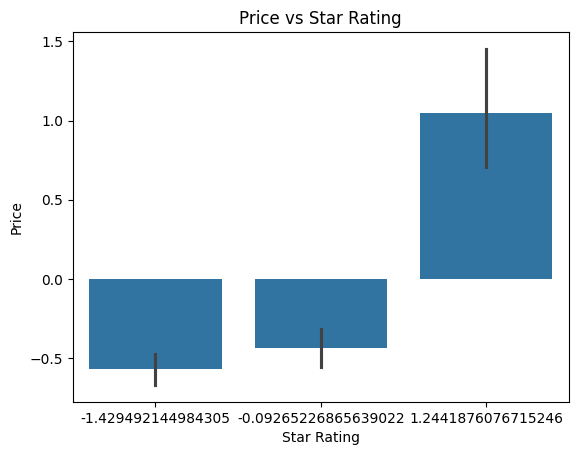

In [ ]:
sns.barplot(x='Star Rating', y='Price', data=df)
plt.title("Price vs Star Rating")
plt.show()

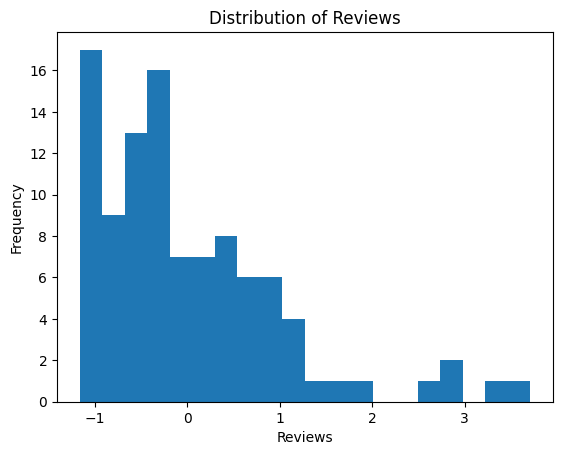

In [ ]:
plt.hist(df['Reviews'], bins=20)
plt.title("Distribution of Reviews")
plt.xlabel("Reviews")
plt.ylabel("Frequency")
plt.show()

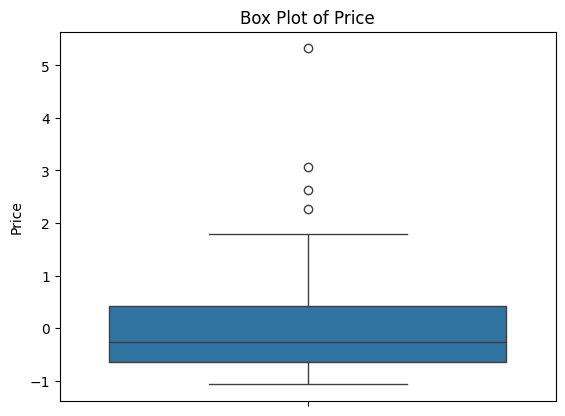

In [ ]:
sns.boxplot(y='Price', data=df)
plt.title("Box Plot of Price")
plt.show()

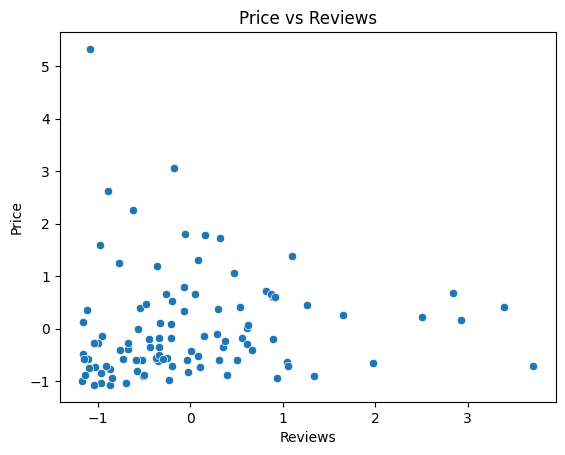

In [ ]:
sns.scatterplot(x='Reviews', y='Price', data=df)
plt.title("Price vs Reviews")
plt.show()

Heatmaps for Correlation Analysis

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_df.corr()
print(corr_matrix)

               Rating   Reviews  Star Rating     Price       Tax
Rating       1.000000 -0.056113     0.477001  0.605186  0.058206
Reviews     -0.056113  1.000000     0.286061  0.053963  0.442635
Star Rating  0.477001  0.286061     1.000000  0.633517  0.306450
Price        0.605186  0.053963     0.633517  1.000000  0.117806
Tax          0.058206  0.442635     0.306450  0.117806  1.000000


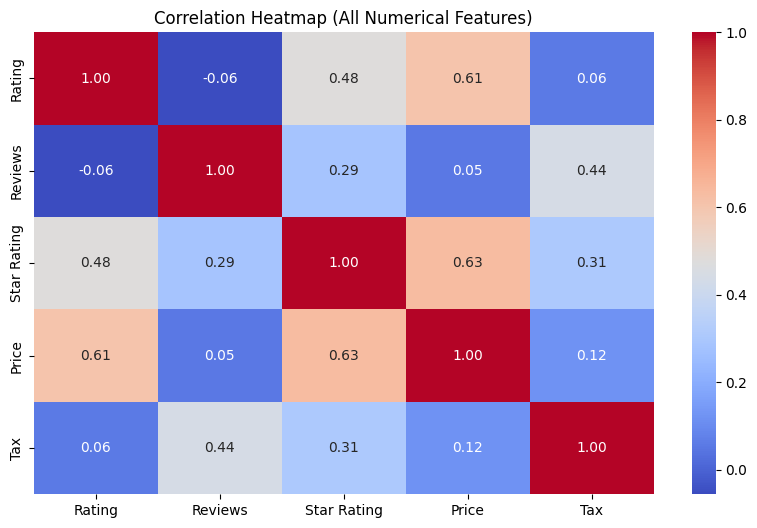

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap (All Numerical Features)")
plt.show()

Grouping and Aggregation Analysis

In [ ]:
agg_df = df.groupby('Star Rating').agg({'Price': ['mean', 'median'], 'Reviews': ['sum', 'count']})
agg_df.columns = ['Avg Price', 'Median Price', 'Total Reviews', 'Review Count']

##Grouped Bar Plot

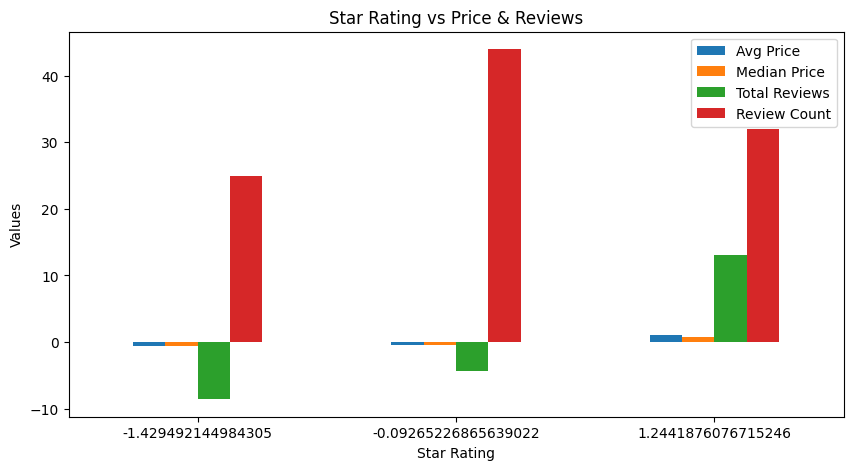

In [ ]:
agg_df.plot(kind='bar', figsize=(10,5))
plt.title('Star Rating vs Price & Reviews')
plt.xlabel('Star Rating')
plt.ylabel('Values')
plt.xticks(rotation=0)
plt.show()

##Separate Bar Plot

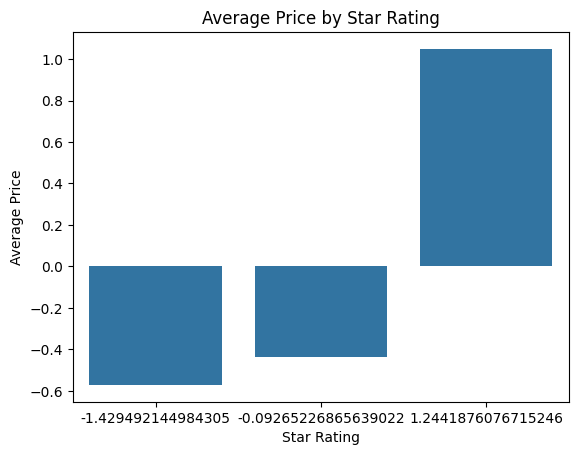

In [ ]:
import seaborn as sns

sns.barplot(x=agg_df.index, y=agg_df['Avg Price'])
plt.title("Average Price by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Price")
plt.show()

##Line Plot

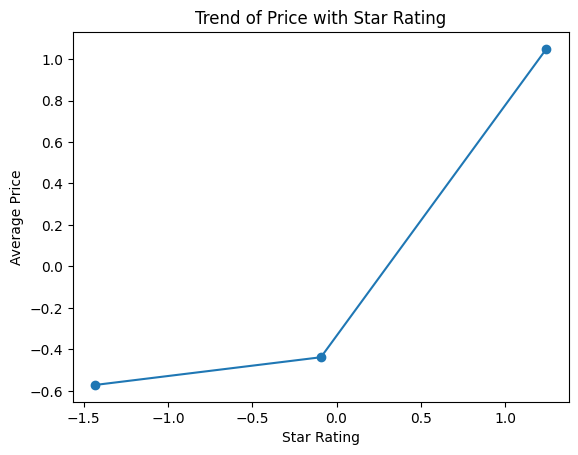

In [ ]:
plt.plot(agg_df.index, agg_df['Avg Price'], marker='o')
plt.title("Trend of Price with Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Price")
plt.show()

##Dual Comparison

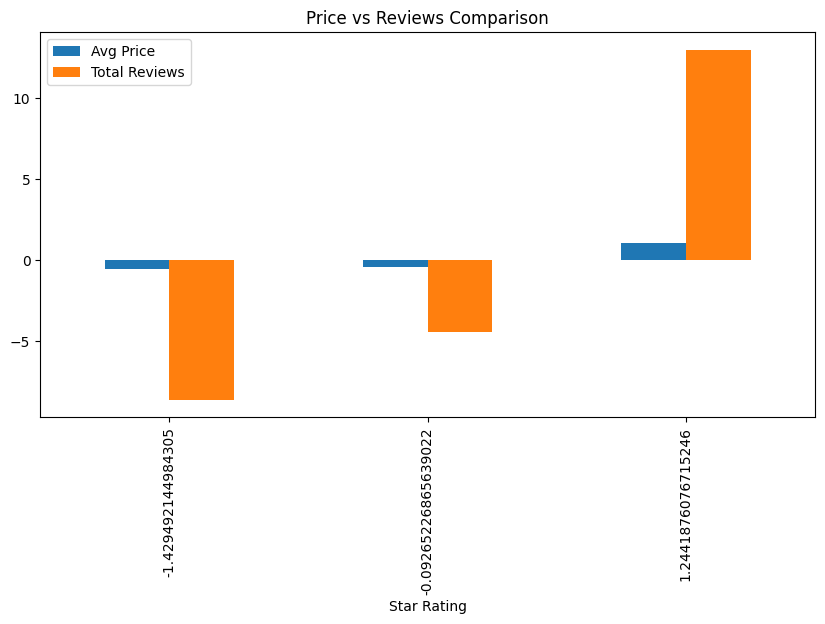

In [ ]:
agg_df[['Avg Price', 'Total Reviews']].plot(kind='bar', figsize=(10,5))
plt.title("Price vs Reviews Comparison")
plt.show()

#Save Cleaned CSV file

In [ ]:
df.to_csv('Bangalore_clean.csv')

In [ ]:
df1 = pd.read_csv('/content/Bangalore_clean.csv')
df

,Hotel Name,Rating,Reviews,Star Rating,Price,Tax,Location_0,Location_1,Location_2,Location_3,...,Location_30,Location_31,Location_32,Location_33,Location_34,Location_35,Location_36,Rating Description_0,Rating Description_1,Rating Description_2
0,The Park Bangalore,-0.397149,2.843888,1.244188,0.682383,4.675436,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,"Keys Select by Lemon Tree Hotels, Whitefield, ...",-0.109607,0.936172,-0.092652,-0.931483,-0.485117,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
2,ITC Windsor - A Luxury Collection Hotel,1.040559,0.085097,1.244188,1.303900,-0.386279,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,Lemon Tree Premier Ulsoor Lake Bangalore,-0.109607,3.710332,1.244188,-0.708237,0.673986,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
4,"Keys Select by Lemon Tree Hotels, Hosur Road, ...",-0.109607,1.982246,-0.092652,-0.661617,0.961515,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Shravanthi Sarovar Portico JP Nagar,-1.259774,-1.044547,-0.092652,-0.274001,0.332545,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
97,"Vivanta Bengaluru, Whitefield",0.753017,-0.256870,1.244188,0.664534,-0.386279,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
98,Melange Astris\nLike a 3,0.177934,-0.211723,-0.092652,-0.187953,0.826736,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
99,Octave Church Inn,-1.547316,-0.494134,-1.429492,-0.888858,-1.066166,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
# Exporting cleaned dataframe into a csv file

df.to_csv('Bangalore_clean.csv', index = False)

##**Data Storytelling: Bangalore Hotel Data – Simple Data Story**

#**Introduction**

Bangalore, known as India's "Silicon Valley," attracts a diverse range of visitors, including business travelers, tourists, and students. Understanding hotel pricing, customer reviews, and taxation trends can provide valuable insights for travelers, hoteliers, and investors. This dataset helps us understand how hotel price, rating, reviews, and tax are related in Bangalore. The goal is to identify patterns that can help both customers and hotel owners.

#**Step 1: Dataset Overview - Understanding Hotel Pricing**

From the analysis, we observed that hotel prices increase as the star rating increases.

1–2 star hotels have low prices
3–4 star hotels have moderate prices
5-star hotels have very high prices

This means higher-rated hotels provide more facilities and charge more.

The dataset includes the following attributes for hotels in Bangalore:

Hotel Name

Price (Room Price per Night)

Star Rating (Hotel category from 1 to 5 stars)

Reviews (Total number of customer reviews)

Tax (Tax applied per booking)

Rating Description (e.g., ‘Good’, ‘Excellent’)

Locality (Area in Bangalore, if available)

#**Initial Observations:**

The dataset contained missing values, which were handled using median and mode imputation.

Duplicate records were found and removed.

Some columns had incorrect data types, which were corrected for analysis.

#**Step 2: Price Trends Across Hotel Categories**

#Insights:

Luxury hotels (5-star): Highest average room prices, often exceeding INR 20,000 per night.

Mid-range hotels (3-star & 4-star): Most common category, with prices typically between INR 3,000 to 10,000.

Budget hotels (1-star & 2-star): Lowest prices, often below INR 3,000 per night.

#Key Takeaways:

Bangalore’s market is dominated by mid-range hotels, catering to business travelers.

Luxury hotels cater to a niche audience, likely high-net-worth individuals and foreign tourists.

Budget hotels have high occupancy rates, but revenue per room is lower.

#**Step 3: Impact of Customer Reviews on Hotel Popularity**

#Observations:

Highly rated hotels (>4 stars) tend to receive more reviews, indicating strong customer engagement.

Some low-rated hotels (<3 stars) still have high review counts, suggesting a mix of both positive and negative guest experiences.

Price and reviews have a weak correlation, meaning expensive hotels do not necessarily receive the most reviews.

#Implications:

Customer service is key: Highly reviewed hotels, regardless of price, are likely offering good experiences.

High-priced hotels must ensure premium service to justify their rates and maintain reputation.

#**Step 4: Budget vs. Luxury Hotels – A Comparative Analysis**

Feature

Budget Hotels (1-2 Star)

Mid-Range Hotels (3-4 Star)

Luxury Hotels (5 Star)

Avg Price

INR 1,500 - 3,000

INR 3,000 - 10,000

INR 15,000+

Avg Reviews

Moderate

High

Moderate

Customer Ratings

Mixed

Mostly Positive

High

Tax Rate

Low

Medium

High

#Key Findings:

Mid-range hotels are the best value-for-money segment for most travelers.

Luxury hotels justify high pricing through exclusivity, amenities, and service.

Budget hotels succeed through volume bookings but may have inconsistent service quality.

#**Step 5: Location-Based Analysis**

(If locality data is available in the dataset)

Trends Across Popular Areas:

Central Business District: High-priced hotels with premium services.

Electronic City & Whitefield: Business hotels catering to IT professionals.

MG Road & Indiranagar: Mid-range hotels with high footfall from tourists.

Outskirts: Budget hotels for economy travelers and students.

#Insights:

Hotels in business districts charge premium prices due to demand from corporate travelers.

Tourist hubs see balanced pricing, with both luxury and budget options available.

Outskirts offer lower-priced stays, appealing to long-term budget-conscious travelers.

#**Step 6: Time-Based Trends (If Available)**

(If date information is included in the dataset, trends can be analyzed by seasonality.)

Peak Seasons: December to February (higher hotel prices due to tourists and business events).

Off-Peak: Monsoon season sees discounts in room pricing.

Festival Seasons: Prices surge around major cultural events and conferences.

#Recommendations:

Travelers can book hotels during off-peak periods for better pricing.

Hoteliers can implement dynamic pricing based on seasonal demand.

#**Step 7: Visual Analysis & Data Visualization Insights**

Key Visualizations Used:

Price Distribution: Bar & line charts highlight pricing variations.

Scatter Plot (Tax vs. Reviews): Showcases how taxation impacts customer engagement.

Box Plot: Identifies pricing outliers in the dataset.

Heatmap: Displays correlations between price, reviews, star rating, and tax.

#**Final Conclusion & Recommendations**

Mid-range hotels (3-4 stars) dominate Bangalore’s hospitality market and offer the best balance between pricing and customer satisfaction.

Luxury hotels serve a niche segment and must emphasize exceptional service to justify premium pricing.

Budget hotels attract a high volume of guests, but service consistency remains a challenge.

Customer reviews play a vital role in hotel popularity, regardless of price.

Location heavily influences pricing, with central areas demanding a premium.

Seasonality affects hotel prices, creating opportunities for dynamic pricing strategies.

#**Business Recommendations**

#For Travelers:


*   Book during off-peak seasons to save money.

*   Check customer reviews before booking—high price doesn’t always mean better service.

*  Consider locality—business districts are expensive, while outskirts offer budget-friendly options.

#For Hotel Owners:

*  Focus on customer service—well-reviewed hotels attract more guests.
*  Adjust pricing dynamically based on demand patterns.
*  Offer targeted discounts for budget and mid-range travelers to increase occupancy rates.